# Comparative Analysis of BNNs on PovertyMap (WILDS)

In this notebook, we compare two distinct approaches to Bayesian Neural Networks (BNNs) on the PovertyMap dataset from the WILDS benchmark. This task involves predicting the asset wealth index from satellite imagery using a ResNet-18 architecture, and evaluating in-distribution (ID) versus out-of-distribution (OOD) generalization across different country folds.

Through multi-fold validation (Folds A-E), this notebook structurally compares training/inference time overheads, RMSE, Negative Log-Likelihood (NLL), and Calibration Error to benchmark these Bayesian approaches. Multiple configurations of the methods provided by `laplace-torch` and `bayeisan-torch` are looked at, to gauge the effect of choosing certain parameters.

In [1]:
from pathlib import Path
import sys, os, time, copy, json, warnings
import urllib.request
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import norm
from laplace import Laplace
from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss
from wilds import get_dataset

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import (
    checkpoint_exists, load_checkpoint, save_checkpoint, seed_everything,
    regression_metrics, combine_predictive_std, optimize_noise_std_bt,
)

SEED = 42
seed_everything(SEED)

WILDS_ROOT = str(ROOT / "data" / "wilds")
os.makedirs(WILDS_ROOT, exist_ok=True)
CHECKPOINT_BASE = str(ROOT / "notebooks" / "comparison" / "results" / "checkpoints" / "bnn_comparison_povertymap")
os.makedirs(CHECKPOINT_BASE, exist_ok=True)
FIGURES_DIR = str(ROOT / "notebooks" / "comparison" / "results" / "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

metrics_dict = {
    "MAP": defaultdict(list),
    "laplace-torch": defaultdict(list),
    "bayesian-torch": defaultdict(list),
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
warnings.filterwarnings("ignore")
plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "savefig.dpi": 150, "savefig.bbox": "tight"})
print(f"PovertyMap BNN comparison | seed={SEED} | device={device} | checkpoints -> {CHECKPOINT_BASE}")

/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


PovertyMap BNN comparison | seed=42 | device=cuda | checkpoints -> /u/halle/carg/home_at/Documents/BNNs/notebooks/comparison/results/checkpoints/bnn_comparison_povertymap


## Load PovertyMap Dataset (WILDS Official)

Loads the official PovertyMap dataset from the WILDS benchmark. Satellite images (224×224, 8 multi-spectral bands, already mean/std normalized) with target `wealthpooled` (asset wealth index).

WILDS splits (by country):
- `train`: 5 countries in-distribution
- `id_val`: ID validation (subset)
- `id_test`: ID test (subset)
- `val`: OOD validation (held-out country)
- `test`: OOD test (held-out countries)

Folds A-E correspond to 5 different country splits (used as seeds per paper).

In [2]:
WILDS_ROOT = str(ROOT / "data" / "wilds")
os.makedirs(WILDS_ROOT, exist_ok=True)

print("Loading PovertyMap from WILDS...")
dataset = get_dataset(dataset='poverty', download=False, root_dir=WILDS_ROOT)
print(f"Dataset loaded. Total samples: {len(dataset)}")
print(f"Splits: {dataset.split_names}")

Loading PovertyMap from WILDS...
Dataset loaded. Total samples: 19669
Splits: {'train': 'Train', 'id_val': 'ID Val', 'id_test': 'ID Test', 'val': 'OOD Val', 'test': 'OOD Test'}


In [3]:
def poverty_transform(img):
    """Convert the dataset image to float tensor."""
    return img.float()

def get_dataloaders(dataset, batch_size=64):
    """Get train/val/test loaders for the given fold dataset."""
    loaders = {}
    for split_name in ['train', 'id_val', 'id_test', 'val', 'test']:
        split_data = dataset.get_subset(split_name, transform=poverty_transform, frac=1.0)
        loaders[split_name] = DataLoader(
            split_data, batch_size=batch_size, shuffle=(split_name == 'train'),
            num_workers=16, pin_memory=True,
        )
    return loaders

# Quick sanity check on the default (fold A) dataset
test_loaders = get_dataloaders(dataset, batch_size=4)
for X, y, meta in test_loaders['train']:
    print(f"Image batch shape: {X.shape}  (expected: [batch, 8, 224, 224])")
    print(f"Target batch shape: {y.shape}  (expected: [batch, 1])")
    print(f"Metadata shape: {meta.shape}")
    print(f"Target range: [{y.min().item():.4f}, {y.max().item():.4f}]")
    break

Image batch shape: torch.Size([4, 8, 224, 224])  (expected: [batch, 8, 224, 224])
Target batch shape: torch.Size([4, 1])  (expected: [batch, 1])
Metadata shape: torch.Size([4, 4])
Target range: [-0.5755, 1.1394]


## Model: ResNet-18 for Multi-Spectral Satellite Imagery

ResNet-18 adapted for 8-channel inputs. Matches the architecture used in Daxberger et al. (2021) and the WILDS benchmark. First conv layer adapted from 3→8 channels, final FC layer replaced with single-output regression head.

In [4]:
class PovertyResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = resnet18(weights=None)
        # Adapt first conv from 3 -> 8 channels
        self.backbone.conv1 = nn.Conv2d(8, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # Replace final FC layer with single-output regression head
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x)

def create_model(seed=42):
    torch.manual_seed(seed)
    return PovertyResNet()

model = create_model()
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: ResNet-18, total params: {n_params:,}")

# Laplace Redux never trains PovertyMap's ResNet-18 themselves (see utils/wilds_utils.py's
# load_pretrained_wilds_model) -- they download the original WILDS paper's released ERM
# checkpoints from CodaLab. We do the same here instead of training our own MAP from
# scratch, so the MAP/Laplace/BNN comparison starts from the actual weights the paper used.
POVERTY_MODEL_UUIDS = {
    'A': '0xed9774bc15d14a31be7e57517989f8b7',
    'B': '0x30c0de563b694cc58e01d8abb48aa276',
    'C': '0xfc22dbce36be44fe80bddaed4ffb3ff4',
    'D': '0xcb986b1511e54a64bbb14f06be2e17a6',
    'E': '0xdd34b17f9b8b4ea2aa4d9f72ed8573f0',
}
POVERTY_MODEL_URL = 'https://worksheets.codalab.org/rest/bundles/%s/contents/blob/best_model.pth'

def load_pretrained_map_model(fold, checkpoint_dir, device, max_retries=5, retry_delay=15):
    """Load Laplace Redux's actual pre-trained MAP checkpoint for this PovertyMap fold
    (ERM baseline, from the original WILDS paper's released models).

    Key remap verified by direct inspection of the downloaded checkpoint: keys are flat
    'model.<attr>' (e.g. 'model.conv1.weight', 'model.fc.weight', standard torchvision
    ResNet attribute names under a single 'model.' prefix. No separate classifier/
    featurizer split for the ERM algorithm). Stripping the 'model.' prefix and prepending
    'backbone.' gives an exact, complete key match against PovertyResNet's own state_dict
    (strict load_state_dict succeeds with zero missing/unexpected keys, verified directly).
    """
    os.makedirs(checkpoint_dir, exist_ok=True)
    ckpt_path = os.path.join(checkpoint_dir, f"wilds_pretrained_poverty_erm_fold{fold}.pth")

    def _download():
        # urlretrieve has no retry logic at all
        # during a long unattended run would otherwise kill the whole notebook.
        url = POVERTY_MODEL_URL % POVERTY_MODEL_UUIDS[fold]
        for attempt in range(1, max_retries + 1):
            try:
                print(f"  Downloading pre-trained WILDS ERM checkpoint for fold {fold} "
                      f"(attempt {attempt}/{max_retries})...")
                urllib.request.urlretrieve(url, ckpt_path)
                return
            except Exception as e:
                if os.path.exists(ckpt_path):
                    os.remove(ckpt_path)  # never leave a partial/corrupt file cached
                if attempt == max_retries:
                    raise
                print(f"    Download failed ({e!r}); retrying in {retry_delay}s...")
                time.sleep(retry_delay)

    if not os.path.exists(ckpt_path):
        _download()

    try:
        raw = torch.load(ckpt_path, map_location='cpu', weights_only=False)['algorithm']
    except Exception:
        # Cached file is corrupt/incomplete (e.g. left over from an earlier interrupted
        # run before this retry logic existed). Remove and re-download once rather
        # than crashing on a stale bad cache entry.
        if os.path.exists(ckpt_path):
            os.remove(ckpt_path)
        _download()
        raw = torch.load(ckpt_path, map_location='cpu', weights_only=False)['algorithm']

    remapped = {'backbone.' + k[len('model.'):]: v for k, v in raw.items() if k.startswith('model.')}

    model = create_model().to(device)
    model.load_state_dict(remapped, strict=True)
    model.eval()
    return model


Model: ResNet-18, total params: 11,192,705


## Laplace Approximation (Full Last-Layer + GLM Predictive)

Following Daxberger et al. (2021):
- Full covariance over last layer (ResNet-18 last layer is 512×1, small enough for full Hessian)
- prior_precision fixed at 10.0 (matches Laplace Redux's actual released PovertyMap config -- never gridsearch/marglik-tuned); sigma_noise tuned via gradient descent minimizing NLL on ID validation set (an NLL-gridsearched prior_precision alternative is compared separately below)
- GLM predictive: closed-form Gaussian via Jacobian linearization (no MC sampling -- `link_approx`/`n_samples` only apply to the classification link function, not used for this regression task)

In [5]:
class _DropMetaRedux:
    def __init__(self, loader):
        self.loader = loader
    @property
    def dataset(self):
        return self.loader.dataset
    def __iter__(self):
        for X, y, _ in self.loader:
            yield X, y
    def __len__(self):
        return len(self.loader)


def optimize_noise_standard_deviation_redux(model, val_loader, device, lr=1e-1, n_epochs=10):
    """Exact port of Laplace Redux's utils/wilds_utils.optimize_noise_standard_deviation."""
    log_sigma_noise = nn.Parameter(torch.zeros(1, device=device))
    optimizer = optim.Adam([log_sigma_noise], lr=lr)
    gaussian_nll_loss = nn.GaussianNLLLoss(full=True)
    for e in range(n_epochs):
        for X, y in val_loader:
            optimizer.zero_grad()
            y_pred = model(X.to(device))
            if isinstance(y_pred, tuple):
                y_pred = y_pred[0]
            nll = gaussian_nll_loss(y_pred, y.to(device),
                                    torch.ones_like(y_pred) * log_sigma_noise.exp() ** 2)
            nll.backward()
            optimizer.step()
    return log_sigma_noise.exp().item()


def train_laplace_redux_style(map_model, train_loader, val_loader, checkpoint_path=None):
    """Laplace fit matching Laplace Redux's actual PovertyMap config exactly (Daxberger et al.
    2021): last_layer, full GGN Hessian, prior_precision fixed at 10.0 (never optimized --
    confirmed directly from configs/wilds/poverty/wilds-poverty_laplace.yaml + uq.py: no
    optimize_prior_precision key/flag anywhere in the released config or its consuming code
    for this benchmark), sigma_noise tuned via gradient descent on validation NLL (exact port
    of utils/wilds_utils.py's optimize_noise_standard_deviation). This is the headline Laplace
    variant for this notebook -- compared below against an NLL-gridsearch alternative.
    """
    model_la = create_model()
    model_la.load_state_dict(map_model.state_dict())
    model_la = model_la.to(device)
    model_la.eval()  # must precede Laplace()/load_state_dict(): LLLaplace's internal
    # _find_last_layer() forward pass runs in whatever mode the model is currently in,
    # and in train() mode it silently corrupts BatchNorm running stats.

    la = Laplace(model_la, likelihood="regression",
                 subset_of_weights="last_layer", hessian_structure="full",
                 prior_precision=10.0)

    train_loader_la = _DropMetaRedux(train_loader)
    val_loader_la   = _DropMetaRedux(val_loader)

    if checkpoint_exists(checkpoint_path):
        ck = load_checkpoint(checkpoint_path, map_location=device)
        if 'la_state_dict' in ck:
            la.load_state_dict(ck['la_state_dict'])
            print(f'  Loaded laplace-torch: prior_prec={float(la.prior_precision):.4f}, '
                  f'sigma_noise={la.sigma_noise.item():.4f}')
            return la, model_la

    la.fit(train_loader_la)
    # prior_precision stays fixed at 10.0 -- no optimize_prior_precision call, matching redux
    sigma_noise = optimize_noise_standard_deviation_redux(la, val_loader_la, device)
    la.sigma_noise = torch.tensor(sigma_noise, device=device)
    print(f'  Fitted laplace-torch: prior_prec={float(la.prior_precision):.4f}, '
          f'sigma_noise={la.sigma_noise.item():.4f}')

    if checkpoint_path:
        save_checkpoint({'la_state_dict': la.state_dict()}, checkpoint_path)

    return la, model_la


def predict_laplace(la, loader):
    """Predict using Laplace GLM posterior.
    This is the single shared prediction function every Laplace variant in this notebook
    goes through"""
    la.model.eval()
    all_mu, all_std, all_y = [], [], []
    with torch.no_grad():
        for X, y, _ in loader:
            X = X.to(device)
            try:
                f_mu, f_var = la(X, pred_type='glm')
            except torch.linalg.LinAlgError:
                # Emergency floor + retry once: the failed attempt never successfully cached
                # a posterior scale, so the retry recomputes fresh with the floored value.
                la.prior_precision = torch.clamp(la.prior_precision, min=1.0)
                f_mu, f_var = la(X, pred_type='glm')
            sigma_noise = la.sigma_noise.item() if la.sigma_noise is not None else 0.0
            pred_std = combine_predictive_std(f_var.squeeze(), sigma_noise).clamp(min=1e-6)
            all_mu.append(f_mu.squeeze().cpu())
            all_std.append(pred_std.cpu())
            all_y.append(y.squeeze())
    return torch.cat(all_mu).numpy(), torch.cat(all_std).numpy(), torch.cat(all_y).numpy()


## Bayesian-Torch (Flipout + SVI)

Variational Bayes baseline using Bayesian-Torch, following Daxberger et al. (2021):
- Diagonal Gaussian posterior with Flipout estimator
- Prior precision = 1×10⁻⁴ (matching MAP weight_decay=1e-4, i.e. prior_sigma = 1/√(1×10⁻⁴) = 100.0)
- KL downscaling factor = 0.1, following [13] in the paper
- Trained from random initialization (no MOPED)

In [6]:
def train_bayesian_torch(map_model, train_loader, val_loader, n_epochs, lr=1e-3, verbose=True, checkpoint_path=None):
    # prior_precision = weight_decay * N, matching Laplace Redux's actual formula
    # (baselines/bbb/train.py: `args.var0 = 1/(5e-4*len(train_loader.dataset))`, i.e.
    # prior_precision = weight_decay/var0 = weight_decay * N). This N-scaling is required
    # for the KL/N loss scaling below to correctly reduce to a weight-decay-equivalent
    # penalty on the posterior mean, using plain weight_decay (no *N) here would leave
    # the KL term's regularization effectively at ~weight_decay/N, i.e. near zero.
    # WEIGHT_DECAY is the notebook-global constant also used by train_map's optimizer
    TAU = 0.1
    num_data = len(train_loader.dataset)
    prior_precision = WEIGHT_DECAY * num_data

    bt_params = {
        "prior_mu": 0.0, "prior_sigma": (1.0 / prior_precision) ** 0.5,
        "posterior_mu_init": 0.0, "posterior_rho_init": -3.0,
        "type": "Flipout", "moped_enable": False,
    }

    if checkpoint_exists(checkpoint_path):
        checkpoint = load_checkpoint(checkpoint_path, map_location='cpu')
        model_bt = create_model().cpu()
        dnn_to_bnn(model_bt, bt_params)
        model_bt.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint.get('history', {'elbo_loss': [], 'kl_loss': [], 'val_loss': []})
        bvl = min(history['val_loss']) if history.get('val_loss') else float('nan')
        print(f'  Loaded bayesian-torch: best_val_loss={bvl:.6f}')
        return model_bt.to(device), history

    # Train from random init (no MOPED), prior_precision=weight_decay*N, KL factor tau=0.1
    # (paper C.2.1, borrowed from Osawa et al., untuned for this task)
    model_bt = create_model().cpu()
    dnn_to_bnn(model_bt, bt_params)
    model_bt = model_bt.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_bt.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

    history = {'elbo_loss': [], 'kl_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):
        model_bt.train()
        epoch_elbo, epoch_kl = 0.0, 0.0
        for X, y, _ in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            output = model_bt(X)
            kl = get_kl_loss(model_bt)
            mse = criterion(output, y)
            loss = mse + (TAU / num_data) * kl
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_bt.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_elbo += loss.item()
            epoch_kl += kl.item()
        epoch_elbo /= len(train_loader)
        epoch_kl /= len(train_loader)

        model_bt.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, _ in val_loader:
                X, y = X.to(device), y.to(device)
                val_loss += criterion(model_bt(X), y).item()
        val_loss /= len(val_loader)

        history['elbo_loss'].append(epoch_elbo)
        history['kl_loss'].append(epoch_kl)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model_bt.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 20:
                if verbose: print(f'  Early stopping at epoch {epoch+1}')
                break

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}, ELBO: {epoch_elbo:.4f}, '
                  f'KL: {epoch_kl:.4f}, Val MSE: {val_loss:.6f}')

    model_bt.load_state_dict(best_state)
    print(f'  Fitted bayesian-torch: best_val_loss={best_val_loss:.6f}')

    if checkpoint_path:
        save_checkpoint(
            {
                'model_state_dict': model_bt.state_dict(),
                'history': history,
                'seed': SEED,
                'n_epochs': n_epochs,
                'lr': lr,
            },
            checkpoint_path,
        )
    return model_bt, history


def _bt_loop_mc_forward(net, X, n_samples):
    """Always loops (never tiles): shared.optimize_noise_std_bt's default mc_forward_fn
    (shared.bt_mc_forward) would tile the batch n_samples times into one forward pass,
    which is cheap for small models but OOMs here -- id_val_loader's batch_size=256 at
    224x224x8 tiled by n_mc=20 is a 5,120-image ResNet-18 forward pass, and Conv2dFlipout
    additionally clones the input/output at every conv layer for its sign-flip
    perturbation, roughly doubling activation memory on top of that. The loop keeps
    memory bounded to one batch at a time, same as predict_bayesian_torch below.
    """
    return torch.stack([net(X) for _ in range(n_samples)])


In [7]:
def predict_bayesian_torch(model_bt, loader, sigma_bt, n_mc=50):
    """MC-sample predictions from a Bayesian-Torch (Flipout) model on a WILDS loader.

    Uses a Python loop (n_mc sequential forward calls), NOT the batch-tiling trick from
    bayesian-torch's own main_bayesian_flipout_cifar.py example -- that trick tiles the
    whole batch n_mc times into ONE forward pass, which OOMs at this batch_size (256)
    and image size (224x224x8) for a full ResNet-18: n_mc=50 would tile to a 12,800-image
    forward pass, and Conv2dFlipout additionally clones the input/output at every conv
    layer for its sign-flip perturbation. The loop keeps memory bounded to one batch at
    a time, same as the original implementation.

    Returns (mean, std, targets) where std = sqrt(epistemic_var + sigma_bt**2),
    sigma_bt being the NLL-minimized aleatoric estimate from optimize_noise_std_bt (called
    with _bt_loop_mc_forward, defined above).
    Previously this function returned the MC std alone with the aleatoric term dropped
    entirely -- fixed to match how Laplace's sigma_noise is composed into its own total
    predictive std elsewhere in this notebook.
    """
    model_bt.eval()
    all_mu, all_std, all_y = [], [], []
    with torch.no_grad():
        for X, y, _ in loader:
            X = X.to(device)
            samples = torch.stack([model_bt(X).squeeze(-1) for _ in range(n_mc)])  # (n_mc, B)
            mu = samples.mean(0)
            epi_std = samples.std(0).clamp(min=1e-6)
            total_std = combine_predictive_std(epi_std, sigma_bt)
            all_mu.append(mu.cpu())
            all_std.append(total_std.cpu())
            all_y.append(y.squeeze())
    return torch.cat(all_mu).numpy(), torch.cat(all_std).numpy(), torch.cat(all_y).numpy()


## 7. Evaluation Metrics

Following Daxberger et al. (2021): MSE, NLL, and Regression Calibration Error (Kuleshov et al. 2018).

In [8]:
# Canonical regression metrics (RMSE, NLL, two-sided Calibration_MAE) come from
# shared.regression_metrics, used throughout this notebook. Kuleshov calibration below
# is the one exception -- Laplace Redux's specific one-sided formula, not covered by
# shared.regression_metrics's two-sided version.

def compute_kuleshov_calibration(y_true, y_pred_mean, y_pred_std, M=10):
    """Kuleshov et al. (2018) Eq. 3 one-sided regression calibration error —
    matches Laplace Redux's get_calib_regression exactly: cal = T * MSE(p, p_hat),
    where p_hat(p) = fraction of points with predictive-CDF(y) <= p, scanned over
    p in [0, 1]. This is the specific formula Laplace Redux plots as "regression
    calibration error" for PovertyMap (Fig. 6/10).
    """
    T = len(y_true)
    ps = np.linspace(0, 1, M)
    cdf_vals = norm.cdf(y_true, loc=y_pred_mean, scale=y_pred_std)
    p_hats = np.array([np.mean(cdf_vals <= p) for p in ps])
    return float(T * np.mean((ps - p_hats) ** 2))

def print_results(results, seeds):
    print("\n" + "=" * 100)
    print(f"POVERTYMAP BNN COMPARISON ({len(seeds)} seeds) — Following Laplace Redux (2021)")
    print("=" * 100)
    for split_name in ['id_test', 'test']:
        label = 'IN-DISTRIBUTION (ID)' if split_name == 'id_test' else 'OUT-OF-DISTRIBUTION (OOD)'
        print(f"\n{'─'*80}\n  {label}\n{'─'*80}")
        print(f"{'Method':20s} {'RMSE':16s} {'NLL':16s} {'Cal_MAE':16s}")
        print(f"{'─'*80}")
        for method, mname in [('map', 'MAP'), ('laplace', 'laplace-torch'), ('bayesian_torch', 'bayesian-torch')]:
            if method not in results[split_name]:
                continue
            m = results[split_name][method]
            if method == 'map':
                # deterministic point estimate: only RMSE is meaningful, no sigma exists
                # for NLL/Cal_MAE (see the main loop's MAP block)
                print(f"{mname:20s}{np.mean(m['rmse']):.4f}±{np.std(m['rmse']):.4f}")
                continue
            print(f"{mname:20s}"
                  f"{np.mean(m['rmse']):.4f}±{np.std(m['rmse']):.4f}  "
                  f"{np.mean(m['nll']):.4f}±{np.std(m['nll']):.4f}  "
                  f"{np.mean(m['cal_mae']):.4f}±{np.std(m['cal_mae']):.4f}")
    print()


## 8. Main Run: 5 Folds (Seeds)

Loops over WILDS folds A-E (equivalent to 5 seeds per Daxberger et al. 2021). For each fold:
1. Load MAP from the pretrained WILDS ERM checkpoint (fold's held-out countries)
2. Fit Laplace (full last-layer + GLM predictive), redux-style: prior_precision fixed at 10.0, sigma_noise tuned on ID val
3. Train Bayesian-Torch (Flipout + MOPED) initialized from MAP
4. Evaluate on both ID and OOD test splits

In [9]:
BATCH_SIZE = 256
N_EPOCHS_BT = 1000
N_MC_BAYES = 50
LR = 1e-3
WEIGHT_DECAY = 1e-4  # single source of truth: used by both train_map's optimizer and the BT prior_precision formula
FOLDS = ['A', 'B', 'C', 'D', 'E']

all_results = {
    split: {
        'map':            {'rmse': []},  # MAP: deterministic point estimate, RMSE + timing only (no sigma to report NLL/Cal_MAE/Cov95 with)
        'laplace':        {'rmse': [], 'nll': [], 'cal_mae': []},
        'bayesian_torch': {'rmse': [], 'nll': [], 'cal_mae': []},
    }
    for split in ['id_test', 'test']
}
all_full_metrics = {split: {'map': [], 'laplace': [], 'bayesian_torch': []} for split in ['id_test', 'test']}
all_raw_preds    = {split: {'map': [], 'laplace': [], 'bayesian_torch': []} for split in ['id_test', 'test']}

for fold_idx, fold in enumerate(FOLDS):
    print(f"\n{'='*70}\nFOLD {fold} ({fold_idx+1}/{len(FOLDS)})\n{'='*70}")

    fold_dataset = get_dataset(dataset='poverty', download=False, root_dir=WILDS_ROOT, fold=fold)
    loaders = get_dataloaders(fold_dataset, batch_size=BATCH_SIZE)
    train_loader    = loaders['train']
    id_val_loader   = loaders['id_val']
    id_test_loader  = loaders['id_test']
    ood_test_loader = loaders['test']

    bt_checkpoint_path     = os.path.join(CHECKPOINT_BASE, f'bnn_fold_{fold}_seed{SEED}.pt')
    laplace_checkpoint_path = os.path.join(CHECKPOINT_BASE, f'laplace_redux_style_fold_{fold}_seed{SEED}.pt')

    # === MAP ===
    # Loaded, not trained: matches Laplace Redux's own methodology (utils/wilds_utils.py's
    # load_pretrained_wilds_model downloads the original WILDS paper's released ERM
    # checkpoint rather than training PovertyMap's ResNet-18 themselves). "Train_Time" here
    # is actually download+load time (near-zero once cached locally).
    print("\n  [MAP]")
    start_time = time.time()
    map_model = load_pretrained_map_model(fold, CHECKPOINT_BASE, device)
    print(f'  Loaded MAP: pretrained WILDS ERM checkpoint (fold {fold})')
    metrics_dict["MAP"]["Train_Time"].append(time.time() - start_time)

    # MAP is a deterministic point estimate with no output variance -- only accuracy
    # (RMSE) and timing/overhead are meaningful for it. NLL/Cal_MAE need a
    # sigma that doesn't exist for MAP and aren't reported; Laplace's predictive mean
    # equals the MAP forward pass anyway, so accuracy comparisons against MAP are only
    # informative for Bayesian-Torch, which actually changes the weights via training.
    for split_name, split_loader in [('id_test', id_test_loader), ('test', ood_test_loader)]:
        inf_start = time.time()
        mu_map, y_map = [], []
        with torch.no_grad():
            for X, y, _ in split_loader:
                mu_map.append(map_model(X.to(device)).squeeze().cpu())
                y_map.append(y.squeeze())
        metrics_dict["MAP"][f"Inference_Time_{split_name}"].append(time.time() - inf_start)

        mu_map = torch.cat(mu_map).numpy()
        y_map  = torch.cat(y_map).numpy()
        rmse_map = float(np.sqrt(np.mean((y_map - mu_map) ** 2)))
        mae_map  = float(np.mean(np.abs(y_map - mu_map)))

        all_full_metrics[split_name]['map'].append({'RMSE': rmse_map, 'MAE': mae_map})
        all_results[split_name]['map']['rmse'].append(rmse_map)
        print(f"  MAP {split_name}: RMSE={rmse_map:.4f}")

    # === Laplace ===
    print("\n  [laplace-torch]")
    start_time = time.time()
    la, _ = train_laplace_redux_style(map_model, train_loader, id_val_loader,
                                      checkpoint_path=laplace_checkpoint_path)
    metrics_dict["laplace-torch"]["Train_Time"].append(time.time() - start_time)

    for split_name, split_loader in [('id_test', id_test_loader), ('test', ood_test_loader)]:
        inf_start = time.time()
        f_mu_la, pred_std_la, y_la = predict_laplace(la, split_loader)
        metrics_dict["laplace-torch"][f"Inference_Time_{split_name}"].append(time.time() - inf_start)

        full_m = regression_metrics(y_la, f_mu_la, pred_std_la)
        all_full_metrics[split_name]['laplace'].append(full_m)
        all_raw_preds[split_name]['laplace'].append((f_mu_la, pred_std_la, y_la))
        all_results[split_name]['laplace']['rmse'].append(full_m['RMSE'])
        all_results[split_name]['laplace']['nll'].append(full_m['NLL'])
        all_results[split_name]['laplace']['cal_mae'].append(full_m['Calibration_MAE'])
        print(f"  laplace-torch {split_name}: RMSE={full_m['RMSE']:.4f}, NLL={full_m['NLL']:.4f}, "
              f"Cal_MAE={full_m['Calibration_MAE']:.4f}")

    # Free Laplace + MAP model from GPU before BT training
    del la
    map_model.cpu()
    torch.cuda.empty_cache()

    # === Bayesian-Torch ===
    print("\n  [bayesian-torch]")
    start_time = time.time()
    model_bt, bt_history = train_bayesian_torch(
        map_model, train_loader, id_val_loader,
        n_epochs=N_EPOCHS_BT, lr=LR, verbose=(fold_idx == 0),
        checkpoint_path=bt_checkpoint_path,
    )
    metrics_dict["bayesian-torch"]["Train_Time"].append(time.time() - start_time)

    # Aleatoric noise: NLL-minimized on validation data, same technique used for
    # map_sigma_noise/Laplace's sigma_noise above -- previously this BT arm had no
    # aleatoric term at all (MC epistemic std alone used as total std).
    sigma_bt = optimize_noise_std_bt(model_bt, _DropMetaRedux(id_val_loader), device,
                                       mc_forward_fn=_bt_loop_mc_forward)
    print(f"  bayesian-torch: sigma_noise={sigma_bt:.4f}")

    for split_name, split_loader in [('id_test', id_test_loader), ('test', ood_test_loader)]:
        inf_start = time.time()
        f_mu_bt, f_sigma_bt, y_bt = predict_bayesian_torch(model_bt, split_loader, sigma_bt, n_mc=N_MC_BAYES)
        metrics_dict["bayesian-torch"][f"Inference_Time_{split_name}"].append(time.time() - inf_start)

        full_m = regression_metrics(y_bt, f_mu_bt, f_sigma_bt)
        all_full_metrics[split_name]['bayesian_torch'].append(full_m)
        all_raw_preds[split_name]['bayesian_torch'].append((f_mu_bt, f_sigma_bt, y_bt))
        all_results[split_name]['bayesian_torch']['rmse'].append(full_m['RMSE'])
        all_results[split_name]['bayesian_torch']['nll'].append(full_m['NLL'])
        all_results[split_name]['bayesian_torch']['cal_mae'].append(full_m['Calibration_MAE'])
        print(f"  bayesian-torch {split_name}: RMSE={full_m['RMSE']:.4f}, NLL={full_m['NLL']:.4f}, "
              f"Cal_MAE={full_m['Calibration_MAE']:.4f}")

    del model_bt
    torch.cuda.empty_cache()


FOLD A (1/5)

  [MAP]


  Loaded MAP: pretrained WILDS ERM checkpoint (fold A)
  MAP id_test: RMSE=0.4516
  MAP test: RMSE=0.5080

  [laplace-torch]
  Loaded laplace-torch: prior_prec=10.0000, sigma_noise=0.4503
  laplace-torch id_test: RMSE=0.4516, NLL=0.6240, Cal_MAE=0.0560
  laplace-torch test: RMSE=0.5080, NLL=0.7546, Cal_MAE=0.0294

  [bayesian-torch]
  Loaded bayesian-torch: best_val_loss=0.182287
  bayesian-torch: sigma_noise=0.4077
  bayesian-torch id_test: RMSE=0.4032, NLL=0.5085, Cal_MAE=0.0740
  bayesian-torch test: RMSE=0.5276, NLL=0.8391, Cal_MAE=0.0606

FOLD B (2/5)

  [MAP]
  Loaded MAP: pretrained WILDS ERM checkpoint (fold B)
  MAP id_test: RMSE=0.5110
  MAP test: RMSE=0.4187

  [laplace-torch]
  Loaded laplace-torch: prior_prec=10.0000, sigma_noise=0.4816
  laplace-torch id_test: RMSE=0.5110, NLL=0.7511, Cal_MAE=0.0090
  laplace-torch test: RMSE=0.4187, NLL=0.5662, Cal_MAE=0.0477

  [bayesian-torch]
  Loaded bayesian-torch: best_val_loss=0.161785
  bayesian-torch: sigma_noise=0.3821
  bayesi

## 9. Results Summary and Metrics Export

Aggregates theoretical and computed metrics over all folds (A-E) into a structured DataFrame to measure training time overhead, test set RMSE/NLL, calibration error, and inference efficiency across strategies. Finally, exports to CSV.

In [10]:
print_results(all_results, FOLDS)

# Extended summary using shared.regression_metrics (RMSE, NLL, Calibration_MAE --
# matches Laplace Redux's reported regression metrics, see Fig. 6/10)
metric_keys = ['RMSE', 'NLL', 'Calibration_MAE']
summary_rows = []
for split_name, split_label in [('id_test', 'ID'), ('test', 'OOD')]:
    for method, mname in [('map', 'MAP'), ('laplace', 'laplace-torch'), ('bayesian_torch', 'bayesian-torch')]:
        fold_dicts = all_full_metrics[split_name][method]
        row = {'Method': mname, 'Split': split_label}
        for k in metric_keys:
            vals = [d[k] for d in fold_dicts if k in d]
            if vals:
                row[f'{k}_mean'] = float(np.mean(vals))
                row[f'{k}_std']  = float(np.std(vals))
        summary_rows.append(row)

df_full = pd.DataFrame(summary_rows).set_index(['Split', 'Method'])
mean_cols = [c for c in df_full.columns if c.endswith('_mean')]
std_cols  = [c for c in df_full.columns if c.endswith('_std')]

print("\n=== Consistent Cross-Notebook Metrics (shared.regression_metrics) ===")
display(df_full[mean_cols + std_cols].round(4))

# Timing summary
rk_map = {'MAP': 'map', 'laplace-torch': 'laplace', 'bayesian-torch': 'bayesian_torch'}
summary_dict = {}
for label in ['MAP', 'laplace-torch', 'bayesian-torch']:
    md = {}
    if label in metrics_dict and 'Train_Time' in metrics_dict[label]:
        md['Mean_Train_Time (s)']   = np.mean(metrics_dict[label]['Train_Time'])
        md['Mean_Inf_Time_ID (s)']  = np.mean(metrics_dict[label]['Inference_Time_id_test'])
        md['Mean_Inf_Time_OOD (s)'] = np.mean(metrics_dict[label]['Inference_Time_test'])
    rk = rk_map[label]
    if rk in all_results['id_test']:
        md['ID_RMSE_mean']    = np.mean(all_results['id_test'][rk]['rmse'])
        md['ID_RMSE_std']     = np.std(all_results['id_test'][rk]['rmse'])
        md['OOD_RMSE_mean']   = np.mean(all_results['test'][rk]['rmse'])
        md['OOD_RMSE_std']    = np.std(all_results['test'][rk]['rmse'])
        if label != 'MAP':  # MAP: no sigma, so no NLL/Cal_MAE to report
            md['ID_NLL_mean']     = np.mean(all_results['id_test'][rk]['nll'])
            md['ID_Cal_MAE_mean'] = np.mean(all_results['id_test'][rk]['cal_mae'])
            md['OOD_NLL_mean']    = np.mean(all_results['test'][rk]['nll'])
            md['OOD_Cal_MAE_mean']= np.mean(all_results['test'][rk]['cal_mae'])
    summary_dict[label] = md

df_timing = pd.DataFrame(summary_dict).T
print("\n=== Timing + Aggregated Metrics ===")
print(df_timing.to_string(float_format="%.4f"))

os.makedirs('results/metrics', exist_ok=True)
df_full.to_csv('results/metrics/povertymap_full_metrics.csv')
df_timing.to_csv('povertymap_bnn_comparison_metrics.csv')
print("\nExported: povertymap_bnn_comparison_metrics.csv, results/metrics/povertymap_full_metrics.csv")



POVERTYMAP BNN COMPARISON (5 seeds) — Following Laplace Redux (2021)

────────────────────────────────────────────────────────────────────────────────
  IN-DISTRIBUTION (ID)
────────────────────────────────────────────────────────────────────────────────
Method               RMSE             NLL              Cal_MAE         
────────────────────────────────────────────────────────────────────────────────
MAP                 0.4494±0.0371
laplace-torch       0.4494±0.0371  0.6205±0.0832  0.0305±0.0217
bayesian-torch      0.4070±0.0199  0.5231±0.0522  0.0528±0.0160

────────────────────────────────────────────────────────────────────────────────
  OUT-OF-DISTRIBUTION (OOD)
────────────────────────────────────────────────────────────────────────────────
Method               RMSE             NLL              Cal_MAE         
────────────────────────────────────────────────────────────────────────────────
MAP                 0.5159±0.0539
laplace-torch       0.5159±0.0539  0.8193±0.1494  0

RMSE_mean  NLL_mean  Calibration_MAE_mean  RMSE_std  \
Split Method                                                                
ID    MAP                0.4494       NaN                   NaN    0.0371   
      laplace-torch      0.4494    0.6205                0.0305    0.0371   
      bayesian-torch     0.4070    0.5231                0.0528    0.0199   
OOD   MAP                0.5159       NaN                   NaN    0.0539   
      laplace-torch      0.5159    0.8193                0.0465    0.0539   
      bayesian-torch     0.5160    0.8338                0.0455    0.0347   

                      NLL_std  Calibration_MAE_std  
Split Method                                        
ID    MAP                 NaN                  NaN  
      laplace-torch    0.0832               0.0217  
      bayesian-torch   0.0522               0.0160  
OOD   MAP                 NaN                  NaN  
      laplace-torch    0.1494               0.0096  
      bayesian-torch   0.1065               0.0192


=== Timing + Aggregated Metrics ===
                Mean_Train_Time (s)  Mean_Inf_Time_ID (s)  Mean_Inf_Time_OOD (s)  ID_RMSE_mean  ID_RMSE_std  OOD_RMSE_mean  OOD_RMSE_std  ID_NLL_mean  ID_Cal_MAE_mean  OOD_NLL_mean  OOD_Cal_MAE_mean
MAP                          0.6003                4.8044                21.1748        0.4494       0.0371         0.5159        0.0539          NaN              NaN           NaN               NaN
laplace-torch                3.8381                2.1145                 3.0018        0.4494       0.0371         0.5159        0.0539       0.6205           0.0305        0.8193            0.0465
bayesian-torch               0.1753               16.9096                61.0839        0.4070       0.0199         0.5160        0.0347       0.5231           0.0528        0.8338            0.0455

Exported: povertymap_bnn_comparison_metrics.csv, results/metrics/povertymap_full_metrics.csv


## 10. Results Visualization

Bar charts comparing Laplace vs Bayesian-Torch on ID and OOD splits.

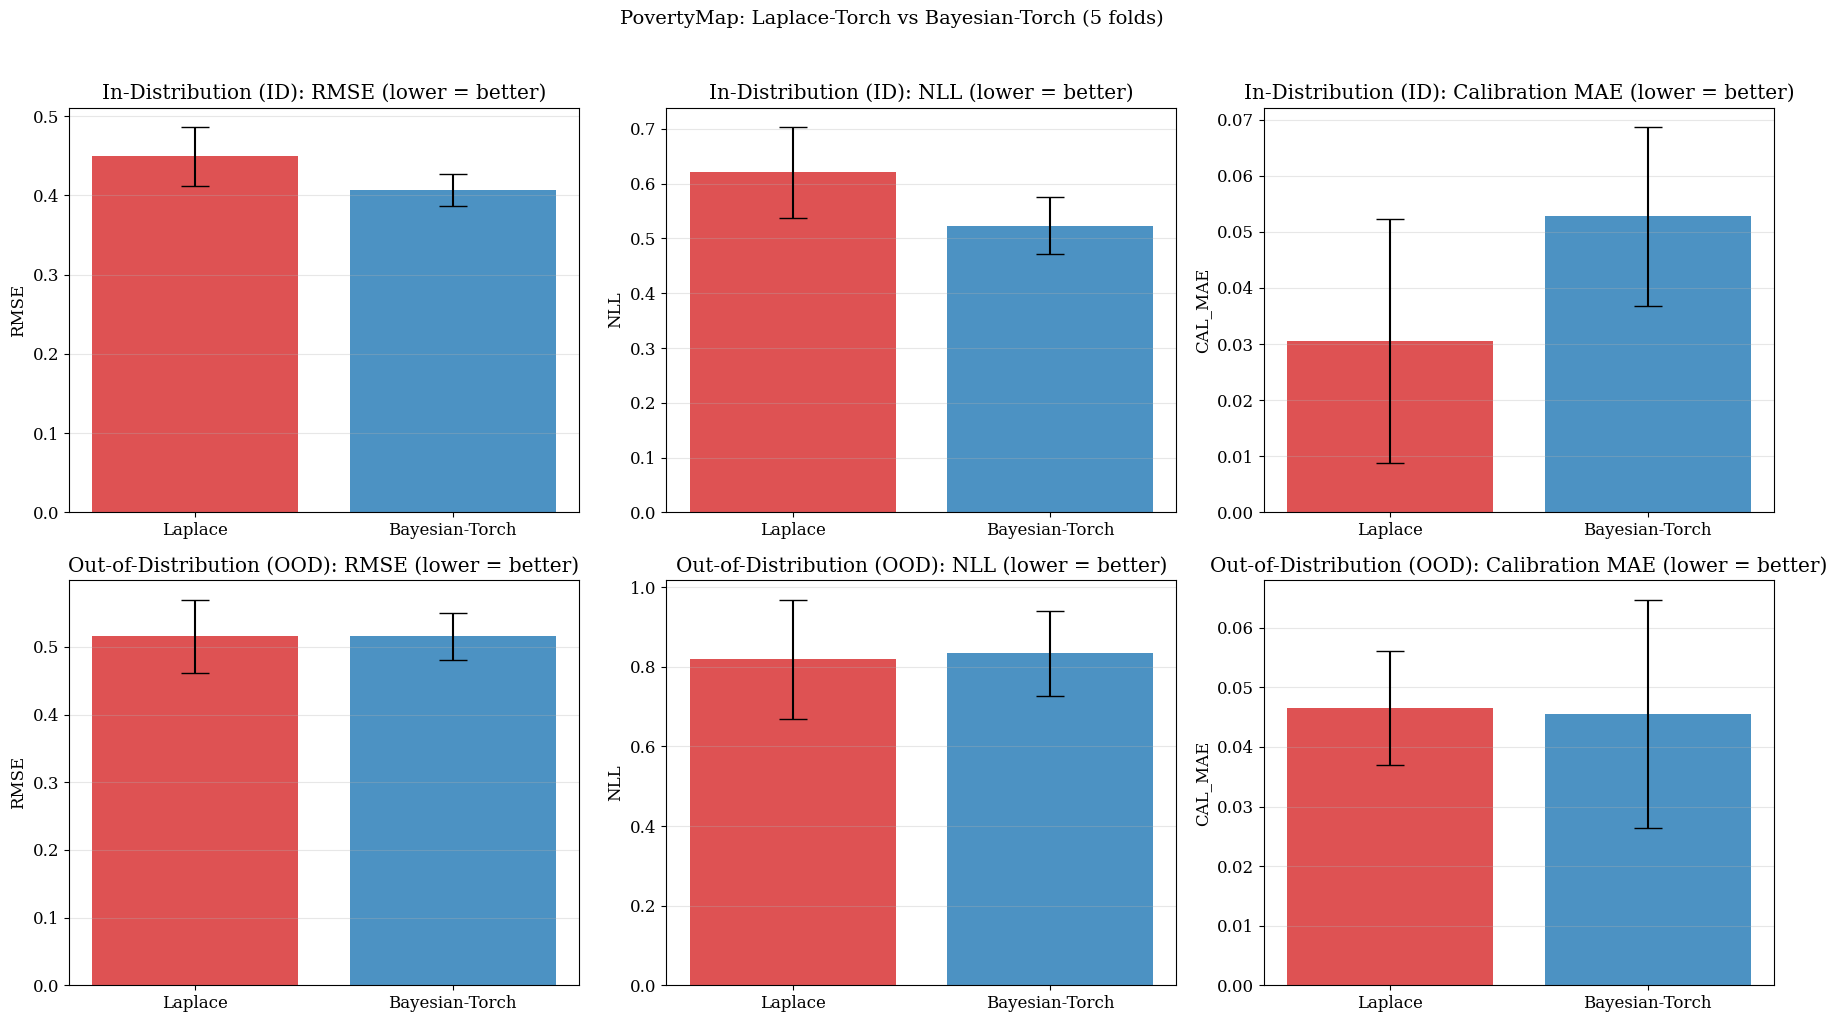

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_metrics = ['rmse', 'nll', 'cal_mae']
titles = ['RMSE (lower = better)', 'NLL (lower = better)', 'Calibration MAE (lower = better)']
colors = ['#d62728', '#1f77b4']

for row, (split_name, split_label) in enumerate(zip(['id_test', 'test'], ['In-Distribution (ID)', 'Out-of-Distribution (OOD)'])):
    for col, (metric, title) in enumerate(zip(plot_metrics, titles)):
        ax = axes[row, col]
        la_vals  = all_results[split_name]['laplace'][metric]
        bt_vals  = all_results[split_name]['bayesian_torch'][metric]
        ax.bar(['Laplace', 'Bayesian-Torch'],
               [np.mean(la_vals), np.mean(bt_vals)],
               yerr=[np.std(la_vals), np.std(bt_vals)],
               capsize=10, color=colors, alpha=0.8)
        ax.set_ylabel(metric.upper())
        ax.set_title(f'{split_label}: {title}')
        ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('PovertyMap: Laplace-Torch vs Bayesian-Torch (5 folds)', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'povertymap_bar_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

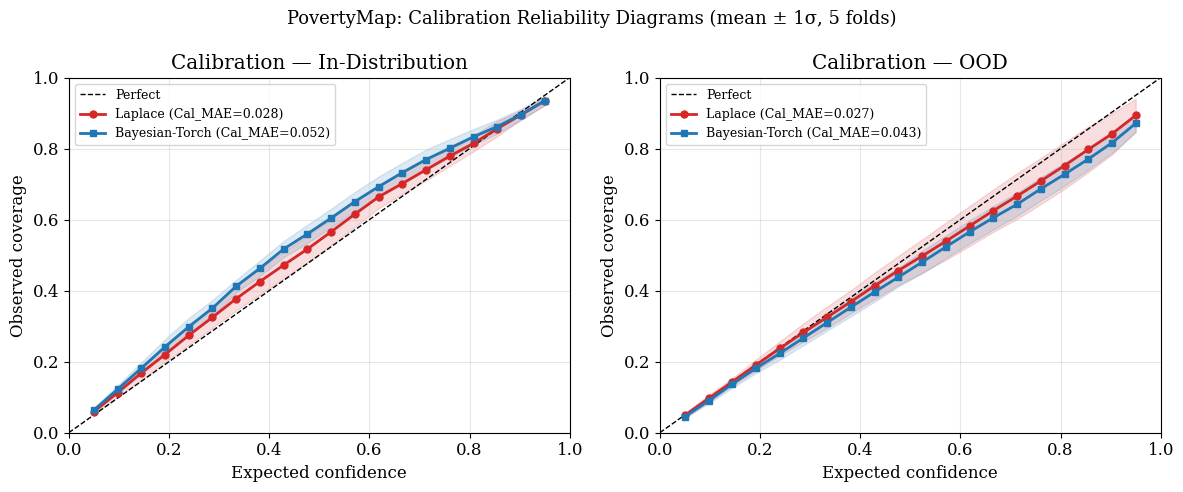

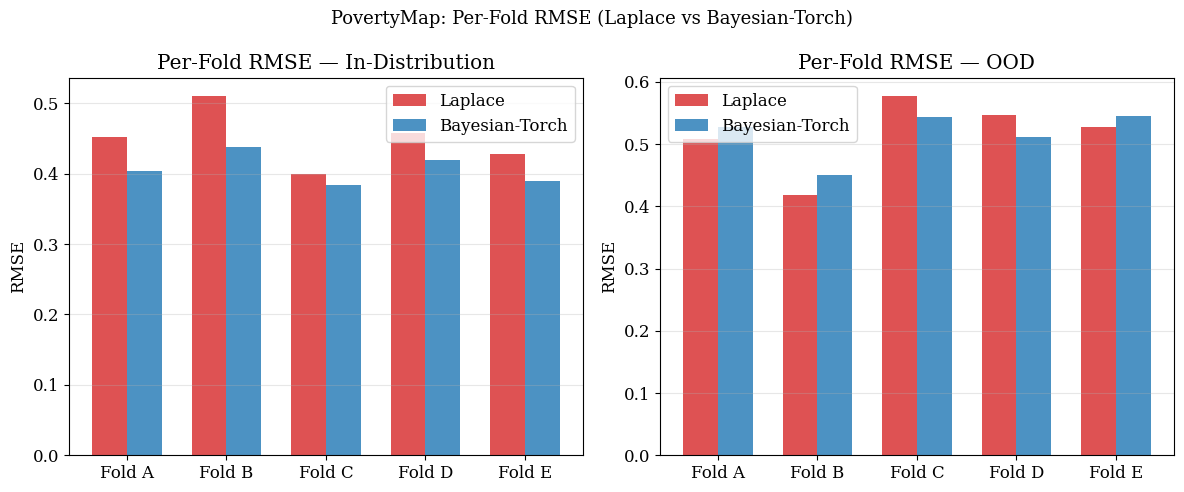

Saved figures to /u/halle/carg/home_at/Documents/BNNs/notebooks/comparison/results/figures


In [12]:
# Calibration reliability diagrams and per-fold RMSE (PovertyMap)
from scipy.stats import norm as _norm

conf_levels = np.linspace(0.05, 0.95, 20)
method_styles = {
    'laplace':        ('Laplace',        '#d62728', 'o'),
    'bayesian_torch': ('Bayesian-Torch', '#1f77b4', 's'),
}

# ── 1. Calibration reliability diagrams: per-fold curves averaged (mean ± 1σ) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (split_name, split_label) in zip(axes, [('id_test', 'In-Distribution'), ('test', 'OOD')]):
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect')
    for method, (label, color, marker) in method_styles.items():
        curves = []
        for mu, std, y in all_raw_preds[split_name][method]:
            z_abs = np.abs((y - mu) / np.clip(std, 1e-12, None))
            curves.append([float(np.mean(z_abs <= _norm.ppf((1.0 + c) / 2.0))) for c in conf_levels])
        curves = np.array(curves)
        mean_obs = curves.mean(0)
        std_obs  = curves.std(0)
        cal_mae = float(np.mean(np.abs(mean_obs - conf_levels)))
        ax.plot(conf_levels, mean_obs, color=color, lw=2, marker=marker, ms=5,
                label=f'{label} (Cal_MAE={cal_mae:.3f})')
        ax.fill_between(conf_levels, mean_obs - std_obs, mean_obs + std_obs, color=color, alpha=0.15)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Expected confidence'); ax.set_ylabel('Observed coverage')
    ax.set_title(f'Calibration — {split_label}')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('PovertyMap: Calibration Reliability Diagrams (mean ± 1σ, 5 folds)', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'povertymap_calibration_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Per-fold RMSE comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(FOLDS))
width = 0.35
for ax, (split_name, split_label) in zip(axes, [('id_test', 'In-Distribution'), ('test', 'OOD')]):
    la_rmse = [all_full_metrics[split_name]['laplace'][i]['RMSE'] for i in range(len(FOLDS))]
    bt_rmse = [all_full_metrics[split_name]['bayesian_torch'][i]['RMSE'] for i in range(len(FOLDS))]
    ax.bar(x - width/2, la_rmse, width, label='Laplace', color='#d62728', alpha=0.8)
    ax.bar(x + width/2, bt_rmse, width, label='Bayesian-Torch', color='#1f77b4', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels([f'Fold {f}' for f in FOLDS])
    ax.set_ylabel('RMSE'); ax.set_title(f'Per-Fold RMSE — {split_label}')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('PovertyMap: Per-Fold RMSE (Laplace vs Bayesian-Torch)', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'povertymap_per_fold_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved figures to {FIGURES_DIR}")

In [13]:
# Kuleshov et al. (2018) Eq. 3 one-sided regression calibration error —
# matches Laplace Redux's actual get_calib_regression, computed per fold from
# already-stored predictions (all_raw_preds). No retraining needed.
print("Kuleshov (2018) one-sided regression calibration error, per method/split (mean \u00b1 std across 5 folds):\n")

kuleshov_results = {split: {} for split in ['id_test', 'test']}
for split_name, split_label in [('id_test', 'ID'), ('test', 'OOD')]:
    for method, mname in [('laplace', 'Laplace'), ('bayesian_torch', 'Bayesian-Torch')]:  # MAP has no sigma, excluded from calibration comparison
        fold_vals = [compute_kuleshov_calibration(y, mu, std)
                     for mu, std, y in all_raw_preds[split_name][method]]
        kuleshov_results[split_name][method] = (float(np.mean(fold_vals)), float(np.std(fold_vals)))
        print(f"  {split_label:4s} {mname:15s}: {np.mean(fold_vals):.4f} \u00b1 {np.std(fold_vals):.4f}")


Kuleshov (2018) one-sided regression calibration error, per method/split (mean ± std across 5 folds):

  ID   Laplace        : 3.3776 ± 1.4606
  ID   Bayesian-Torch : 1.3169 ± 0.3973
  OOD  Laplace        : 32.7960 ± 25.5082
  OOD  Bayesian-Torch : 24.1549 ± 18.8318


In [14]:
# Alternative to the headline redux-style fit: gridsearch prior_precision against an
# explicit Gaussian-NLL loss instead of leaving it fixed at 10.0. optimize_prior_precision's
# regression default (no loss= given) is MeanSquaredError, confirmed from baselaplace.py --
# this variant overrides that default to test whether tuning prior_precision against NLL
# directly changes anything relative to the redux-faithful fixed-precision headline.
#
# NOTE: optimize_prior_precision's offline callable signature is loss(means, variances,
# targets) for regression (variances = epistemic f_var only, NOT including sigma_noise) —
# confirmed from laplace/utils/utils.py's validate(). So sigma_noise must be set to a
# reasonable value BEFORE this gridsearch for the NLL to be meaningful (matching the
# order already used in sinusoidal_laplace.ipynb / two_moons_laplace.ipynb).

def make_gaussian_nll_loss(la):
    """Offline loss(means, variances, targets) using la's current sigma_noise."""
    def _loss(means, variances, targets):
        total_var = variances.squeeze() + la.sigma_noise ** 2
        resid = targets.squeeze() - means.squeeze()
        return torch.mean(0.5 * torch.log(2 * np.pi * total_var) + resid ** 2 / (2 * total_var))
    return _loss


def train_laplace_nll_gridsearch(map_model, train_loader, val_loader, checkpoint_path=None):
    """Same as train_laplace's gridsearch branch, but optimize_prior_precision is given
    an explicit NLL loss instead of the regression default (MSE).
    """
    model_la = create_model()
    model_la.load_state_dict(map_model.state_dict())
    model_la = model_la.to(device)
    model_la.eval()  # must precede Laplace()/load_state_dict(): LLLaplace's internal
    # _find_last_layer() forward pass runs in whatever mode the model is currently in,
    # and in train() mode it silently corrupts BatchNorm running stats (see
    # notebooks/notes/bayesian_torch_diagnostic.md-style diagnostic in the cell below)

    la = Laplace(model_la, likelihood="regression",
                 subset_of_weights="last_layer", hessian_structure="full")

    train_loader_la = _DropMetaRedux(train_loader)
    val_loader_la   = _DropMetaRedux(val_loader)

    if checkpoint_exists(checkpoint_path):
        ck = load_checkpoint(checkpoint_path, map_location=device)
        if 'la_state_dict' in ck:
            la.load_state_dict(ck['la_state_dict'])
            print(f'  Loaded laplace-torch: prior_prec={float(la.prior_precision):.4f}, '
                  f'sigma_noise={la.sigma_noise.item():.4f}')
            return la, model_la

    la.fit(train_loader_la)

    # Reasonable starting sigma_noise before tuning prior_precision against NLL
    # (same pattern as sinusoidal_laplace.ipynb / two_moons_laplace.ipynb)
    map_model.eval()
    with torch.no_grad():
        resid_sq = []
        for X, y in train_loader_la:
            pred = map_model(X.to(device)).squeeze().cpu()
            resid_sq.append((pred - y.squeeze()) ** 2)
        map_resid_std = float(torch.cat(resid_sq).mean().sqrt())
    la.sigma_noise = torch.tensor(map_resid_std, device=device)

    la.optimize_prior_precision(
        method='gridsearch',
        val_loader=val_loader_la,
        pred_type='glm',
        loss=make_gaussian_nll_loss(la),
    )

    # Floor prior_precision away from the near-zero end of the search range (same
    # numerical-stability fix and rationale as train_laplace above).
    la.prior_precision = torch.clamp(la.prior_precision, min=1e-1)

    # Same sigma_noise gridsearch as train_laplace, now with the NLL-tuned prior_precision
    sigma_grid = np.logspace(-2, 1, 30)
    best_nll, best_sigma = float('inf'), 1.0
    with torch.no_grad():
        for sigma in sigma_grid:
            la.sigma_noise = torch.tensor(sigma, device=device)
            nll_total, n_total = 0.0, 0
            failed = False
            for X, y in val_loader_la:
                X = X.to(device)
                try:
                    f_mu, f_var = la(X, pred_type='glm')
                except torch.linalg.LinAlgError:
                    failed = True
                    break
                pred_std = combine_predictive_std(f_var.squeeze(), sigma).clamp(min=1e-6)
                resid = y.squeeze().to(device) - f_mu.squeeze()
                nll_total += (0.5 * np.log(2 * np.pi)
                              + pred_std.log()
                              + 0.5 * (resid / pred_std) ** 2).sum().item()
                n_total += y.size(0)
            avg_nll = float('inf') if failed else nll_total / n_total
            if avg_nll < best_nll:
                best_nll, best_sigma = avg_nll, sigma
    la.sigma_noise = torch.tensor(best_sigma, device=device)
    print(f'  Fitted laplace-torch: prior_prec={float(la.prior_precision):.4f}, '
          f'sigma_noise={la.sigma_noise.item():.4f}, val_nll={best_nll:.4f}')

    if checkpoint_path:
        save_checkpoint({'la_state_dict': la.state_dict()}, checkpoint_path)

    return la, model_la


print("Fitting/loading NLL-gridsearch Laplace across 5 folds...")
nll_gs_results = {'id_test': [], 'test': []}

for fold in FOLDS:
    print(f"\n  Fold {fold}")
    fold_dataset = get_dataset(dataset='poverty', download=False, root_dir=WILDS_ROOT, fold=fold)
    loaders = get_dataloaders(fold_dataset, batch_size=BATCH_SIZE)

    map_model_n = load_pretrained_map_model(fold, CHECKPOINT_BASE, device)

    nll_gs_ckpt = os.path.join(CHECKPOINT_BASE, f'laplace_nll_gridsearch_fold_{fold}_seed{SEED}.pt')
    la_n, _ = train_laplace_nll_gridsearch(map_model_n, loaders['train'], loaders['id_val'],
                                           checkpoint_path=nll_gs_ckpt)

    for split_name, loader in [('id_test', loaders['id_test']), ('test', loaders['test'])]:
        mu, std, y = predict_laplace(la_n, loader)
        m = regression_metrics(y, mu, std)
        nll_gs_results[split_name].append(m)
        print(f"  Fold {fold} {split_name}: RMSE={m['RMSE']:.4f}, NLL={m['NLL']:.4f}, "
              f"Cal_MAE={m['Calibration_MAE']:.4f}")

print("\nNLL-gridsearch Laplace vs. redux-style (headline, prior_precision fixed=10.0):\n")
for split_name, split_label in [('id_test', 'ID'), ('test', 'OOD')]:
    n_rmse = np.mean([m['RMSE'] for m in nll_gs_results[split_name]])
    n_nll  = np.mean([m['NLL'] for m in nll_gs_results[split_name]])
    n_cal  = np.mean([m['Calibration_MAE'] for m in nll_gs_results[split_name]])
    r_rmse = np.mean(all_results[split_name]['laplace']['rmse'])
    r_nll  = np.mean(all_results[split_name]['laplace']['nll'])
    r_cal  = np.mean(all_results[split_name]['laplace']['cal_mae'])
    print(f"  {split_label}: {'nll-gridsearch':15s}RMSE={n_rmse:.4f} NLL={n_nll:.4f} Cal_MAE={n_cal:.4f}")
    print(f"  {split_label}: {'redux-style':15s}RMSE={r_rmse:.4f} NLL={r_nll:.4f} Cal_MAE={r_cal:.4f}\n")


Fitting/loading NLL-gridsearch Laplace across 5 folds...

  Fold A


  Loaded laplace-torch: prior_prec=0.1000, sigma_noise=0.4520
  Fold A id_test: RMSE=0.4516, NLL=0.6238, Cal_MAE=0.0572
  Fold A test: RMSE=0.5080, NLL=0.7499, Cal_MAE=0.0261

  Fold B
  Loaded laplace-torch: prior_prec=0.1000, sigma_noise=0.4520
  Fold B id_test: RMSE=0.5110, NLL=0.7636, Cal_MAE=0.0161
  Fold B test: RMSE=0.4187, NLL=0.5538, Cal_MAE=0.0268

  Fold C
  Loaded laplace-torch: prior_prec=0.1177, sigma_noise=0.4520
  Fold C id_test: RMSE=0.3989, NLL=0.5144, Cal_MAE=0.0810
  Fold C test: RMSE=0.5782, NLL=0.9285, Cal_MAE=0.0368

  Fold D
  Loaded laplace-torch: prior_prec=0.1000, sigma_noise=0.4520
  Fold D id_test: RMSE=0.4579, NLL=0.6377, Cal_MAE=0.0347
  Fold D test: RMSE=0.5474, NLL=0.8556, Cal_MAE=0.0272

  Fold E
  Loaded laplace-torch: prior_prec=0.1000, sigma_noise=0.4520
  Fold E id_test: RMSE=0.4277, NLL=0.5724, Cal_MAE=0.0466
  Fold E test: RMSE=0.5273, NLL=0.8048, Cal_MAE=0.0227

NLL-gridsearch Laplace vs. redux-style (headline, prior_precision fixed=10.0):

  ID

In [15]:
# Tau-annealing schedule variant, following Osawa et al. (2019)'s actual recommendation
# (not the fixed tau=0.1 used above): "We use a schedule where it is increased from a
# small value (e.g., 0.1) to 1." The paper doesn't specify the exact shape, so this uses
# linear annealing over the full training run: tau(epoch) = 0.1 + 0.9 * epoch/(n_epochs-1).
# Same architecture, prior_precision, and KL/num_data scaling as the fixed-tau run above —
# only tau itself changes from a constant to an annealed schedule.

def train_bayesian_torch_tau_schedule(map_model, train_loader, val_loader, n_epochs=1000,
                                      lr=1e-3, verbose=True, checkpoint_path=None):
    # prior_precision = weight_decay * N, matching Redux's actual formula (see train_bayesian_torch)
    # WEIGHT_DECAY is the notebook-global constant also used by train_map's optimizer
    num_data = len(train_loader.dataset)
    prior_precision = WEIGHT_DECAY * num_data

    bt_params = {
        "prior_mu": 0.0, "prior_sigma": (1.0 / prior_precision) ** 0.5,
        "posterior_mu_init": 0.0, "posterior_rho_init": -3.0,
        "type": "Flipout", "moped_enable": False,
    }

    if checkpoint_exists(checkpoint_path):
        checkpoint = load_checkpoint(checkpoint_path, map_location='cpu')
        model_bt = create_model().cpu()
        dnn_to_bnn(model_bt, bt_params)
        model_bt.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint.get('history', {'elbo_loss': [], 'kl_loss': [], 'val_loss': []})
        bvl = min(history['val_loss']) if history.get('val_loss') else float('nan')
        print(f'  Loaded bayesian-torch: best_val_loss={bvl:.6f}')
        return model_bt.to(device), history

    model_bt = create_model().cpu()
    dnn_to_bnn(model_bt, bt_params)
    model_bt = model_bt.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_bt.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

    history = {'elbo_loss': [], 'kl_loss': [], 'val_loss': [], 'tau': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):
        tau = 0.1 + 0.9 * (epoch / max(n_epochs - 1, 1))  # linear anneal 0.1 -> 1.0
        model_bt.train()
        epoch_elbo, epoch_kl = 0.0, 0.0
        for X, y, _ in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            output = model_bt(X)
            kl = get_kl_loss(model_bt)
            mse = criterion(output, y)
            loss = mse + (tau / num_data) * kl
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_bt.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_elbo += loss.item()
            epoch_kl += kl.item()
        epoch_elbo /= len(train_loader)
        epoch_kl /= len(train_loader)

        model_bt.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, _ in val_loader:
                X, y = X.to(device), y.to(device)
                val_loss += criterion(model_bt(X), y).item()
        val_loss /= len(val_loader)

        history['elbo_loss'].append(epoch_elbo)
        history['kl_loss'].append(epoch_kl)
        history['val_loss'].append(val_loss)
        history['tau'].append(tau)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model_bt.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 20:
                if verbose: print(f'  Early stopping at epoch {epoch+1}')
                break

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}, tau={tau:.3f}, ELBO: {epoch_elbo:.4f}, '
                  f'KL: {epoch_kl:.4f}, Val MSE: {val_loss:.6f}')

    model_bt.load_state_dict(best_state)
    print(f'  Fitted bayesian-torch: best_val_loss={best_val_loss:.6f}')

    if checkpoint_path:
        save_checkpoint(
            {'model_state_dict': model_bt.state_dict(), 'history': history,
             'seed': SEED, 'n_epochs': n_epochs, 'lr': lr},
            checkpoint_path,
        )
    return model_bt, history


print("Fitting/loading tau-schedule Bayesian-Torch across 5 folds...")
tau_schedule_results = {'id_test': [], 'test': []}

for fold in FOLDS:
    print(f"\n  Fold {fold}")
    fold_dataset = get_dataset(dataset='poverty', download=False, root_dir=WILDS_ROOT, fold=fold)
    loaders = get_dataloaders(fold_dataset, batch_size=BATCH_SIZE)

    map_model_t = load_pretrained_map_model(fold, CHECKPOINT_BASE, device)

    tau_ckpt = os.path.join(CHECKPOINT_BASE, f'bnn_tau_schedule_fold_{fold}_seed{SEED}.pt')
    bt_t, _ = train_bayesian_torch_tau_schedule(
        map_model_t, loaders['train'], loaders['id_val'],
        n_epochs=N_EPOCHS_BT, lr=LR, verbose=(fold == FOLDS[0]),
        checkpoint_path=tau_ckpt,
    )
    sigma_bt_t = optimize_noise_std_bt(bt_t, _DropMetaRedux(loaders['id_val']), device,
                                         mc_forward_fn=_bt_loop_mc_forward)

    for split_name, loader in [('id_test', loaders['id_test']), ('test', loaders['test'])]:
        mu, std, y = predict_bayesian_torch(bt_t, loader, sigma_bt_t)
        m = regression_metrics(y, mu, std)
        tau_schedule_results[split_name].append(m)
        print(f"  Fold {fold} {split_name}: RMSE={m['RMSE']:.4f}, NLL={m['NLL']:.4f}, "
              f"Cal_MAE={m['Calibration_MAE']:.4f}")

print("\ntau-schedule Bayesian-Torch vs. fixed-tau=0.1 Bayesian-Torch vs. MAP vs. Laplace:\n")
for split_name, split_label in [('id_test', 'ID'), ('test', 'OOD')]:
    s_rmse = np.mean([m['RMSE'] for m in tau_schedule_results[split_name]])
    s_nll  = np.mean([m['NLL'] for m in tau_schedule_results[split_name]])
    s_cal  = np.mean([m['Calibration_MAE'] for m in tau_schedule_results[split_name]])
    b_rmse = np.mean(all_results[split_name]['bayesian_torch']['rmse'])
    b_nll  = np.mean(all_results[split_name]['bayesian_torch']['nll'])
    b_cal  = np.mean(all_results[split_name]['bayesian_torch']['cal_mae'])
    m_rmse = np.mean(all_results[split_name]['map']['rmse'])  # MAP: RMSE only, no sigma for NLL/Cal_MAE
    print(f"  {split_label}: {'tau-schedule':15s}RMSE={s_rmse:.4f} NLL={s_nll:.4f} Cal_MAE={s_cal:.4f}")
    print(f"  {split_label}: {'fixed-tau=0.1':15s}RMSE={b_rmse:.4f} NLL={b_nll:.4f} Cal_MAE={b_cal:.4f}")
    print(f"  {split_label}: {'MAP':15s}RMSE={m_rmse:.4f}\n")


Fitting/loading tau-schedule Bayesian-Torch across 5 folds...

  Fold A
  Loaded bayesian-torch: best_val_loss=0.178455
  Fold A id_test: RMSE=0.4058, NLL=0.5170, Cal_MAE=0.0508
  Fold A test: RMSE=0.5219, NLL=0.8342, Cal_MAE=0.0736

  Fold B
  Loaded bayesian-torch: best_val_loss=0.164685
  Fold B id_test: RMSE=0.4578, NLL=0.6585, Cal_MAE=0.0252
  Fold B test: RMSE=0.4498, NLL=0.6355, Cal_MAE=0.0131

  Fold C
  Loaded bayesian-torch: best_val_loss=0.169499
  Fold C id_test: RMSE=0.3958, NLL=0.4909, Cal_MAE=0.0671
  Fold C test: RMSE=0.5723, NLL=0.9936, Cal_MAE=0.0472

  Fold D
  Loaded bayesian-torch: best_val_loss=0.159191
  Fold D id_test: RMSE=0.4310, NLL=0.5697, Cal_MAE=0.0314
  Fold D test: RMSE=0.5222, NLL=0.8290, Cal_MAE=0.0336

  Fold E
  Loaded bayesian-torch: best_val_loss=0.158718
  Fold E id_test: RMSE=0.4015, NLL=0.5046, Cal_MAE=0.0424
  Fold E test: RMSE=0.5441, NLL=0.9496, Cal_MAE=0.0713

tau-schedule Bayesian-Torch vs. fixed-tau=0.1 Bayesian-Torch vs. MAP vs. Laplace:


In [16]:
# Same as train_bayesian_torch (fixed tau=0.1), but with batch_size substituted for N
# everywhere, isolating just that one axis. This is NOT bayesian_torch's official
# convention (which drops tau entirely) — it's a targeted ablation: does N vs. batch_size
# alone explain the difference, holding tau=0.1 fixed like the original variant.

def train_bayesian_torch_batch_size(map_model, train_loader, val_loader, n_epochs=1000,
                                    lr=1e-3, verbose=True, checkpoint_path=None):
    TAU = 0.1
    batch_size = train_loader.batch_size
    prior_precision = WEIGHT_DECAY * batch_size

    bt_params = {
        "prior_mu": 0.0, "prior_sigma": (1.0 / prior_precision) ** 0.5,
        "posterior_mu_init": 0.0, "posterior_rho_init": -3.0,
        "type": "Flipout", "moped_enable": False,
    }

    if checkpoint_exists(checkpoint_path):
        checkpoint = load_checkpoint(checkpoint_path, map_location='cpu')
        model_bt = create_model().cpu()
        dnn_to_bnn(model_bt, bt_params)
        model_bt.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint.get('history', {'elbo_loss': [], 'kl_loss': [], 'val_loss': []})
        bvl = min(history['val_loss']) if history.get('val_loss') else float('nan')
        print(f'  Loaded bayesian-torch: best_val_loss={bvl:.6f}')
        return model_bt.to(device), history

    model_bt = create_model().cpu()
    dnn_to_bnn(model_bt, bt_params)
    model_bt = model_bt.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_bt.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

    history = {'elbo_loss': [], 'kl_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):
        model_bt.train()
        epoch_elbo, epoch_kl = 0.0, 0.0
        for X, y, _ in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            output = model_bt(X)
            kl = get_kl_loss(model_bt)
            mse = criterion(output, y)
            loss = mse + (TAU / batch_size) * kl
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_bt.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_elbo += loss.item()
            epoch_kl += kl.item()
        epoch_elbo /= len(train_loader)
        epoch_kl /= len(train_loader)

        model_bt.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, _ in val_loader:
                X, y = X.to(device), y.to(device)
                val_loss += criterion(model_bt(X), y).item()
        val_loss /= len(val_loader)

        history['elbo_loss'].append(epoch_elbo)
        history['kl_loss'].append(epoch_kl)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model_bt.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 20:
                if verbose: print(f'  Early stopping at epoch {epoch+1}')
                break

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}, ELBO: {epoch_elbo:.4f}, '
                  f'KL: {epoch_kl:.4f}, Val MSE: {val_loss:.6f}')

    model_bt.load_state_dict(best_state)
    print(f'  Fitted bayesian-torch: best_val_loss={best_val_loss:.6f}')

    if checkpoint_path:
        save_checkpoint(
            {'model_state_dict': model_bt.state_dict(), 'history': history,
             'seed': SEED, 'n_epochs': n_epochs, 'lr': lr},
            checkpoint_path,
        )
    return model_bt, history


print("Fitting/loading batch_size-scaled Bayesian-Torch across 5 folds...")
batch_size_bt_results = {'id_test': [], 'test': []}

for fold in FOLDS:
    print(f"\n  Fold {fold}")
    fold_dataset = get_dataset(dataset='poverty', download=False, root_dir=WILDS_ROOT, fold=fold)
    loaders = get_dataloaders(fold_dataset, batch_size=BATCH_SIZE)

    map_model_bs = load_pretrained_map_model(fold, CHECKPOINT_BASE, device)

    bs_ckpt = os.path.join(CHECKPOINT_BASE, f'bnn_batch_size_fold_{fold}_seed{SEED}.pt')
    bt_bs, _ = train_bayesian_torch_batch_size(
        map_model_bs, loaders['train'], loaders['id_val'],
        n_epochs=N_EPOCHS_BT, lr=LR, verbose=(fold == FOLDS[0]),
        checkpoint_path=bs_ckpt,
    )
    sigma_bt_bs = optimize_noise_std_bt(bt_bs, _DropMetaRedux(loaders['id_val']), device,
                                          mc_forward_fn=_bt_loop_mc_forward)

    for split_name, loader in [('id_test', loaders['id_test']), ('test', loaders['test'])]:
        mu, std, y = predict_bayesian_torch(bt_bs, loader, sigma_bt_bs)
        m = regression_metrics(y, mu, std)
        batch_size_bt_results[split_name].append(m)
        print(f"  Fold {fold} {split_name}: RMSE={m['RMSE']:.4f}, NLL={m['NLL']:.4f}, "
              f"Cal_MAE={m['Calibration_MAE']:.4f}")

print("\nbatch_size-scaled Bayesian-Torch vs. N-scaled (fixed-tau=0.1) vs. MAP:\n")
for split_name, split_label in [('id_test', 'ID'), ('test', 'OOD')]:
    bs_rmse = np.mean([m['RMSE'] for m in batch_size_bt_results[split_name]])
    bs_nll  = np.mean([m['NLL'] for m in batch_size_bt_results[split_name]])
    bs_cal  = np.mean([m['Calibration_MAE'] for m in batch_size_bt_results[split_name]])
    b_rmse = np.mean(all_results[split_name]['bayesian_torch']['rmse'])
    b_nll  = np.mean(all_results[split_name]['bayesian_torch']['nll'])
    b_cal  = np.mean(all_results[split_name]['bayesian_torch']['cal_mae'])
    m_rmse = np.mean(all_results[split_name]['map']['rmse'])  # MAP: RMSE only, no sigma for NLL/Cal_MAE
    print(f"  {split_label}: {'batch_size-scaled':19s}RMSE={bs_rmse:.4f} NLL={bs_nll:.4f} Cal_MAE={bs_cal:.4f}")
    print(f"  {split_label}: {'N-scaled':19s}RMSE={b_rmse:.4f} NLL={b_nll:.4f} Cal_MAE={b_cal:.4f}")
    print(f"  {split_label}: {'MAP':19s}RMSE={m_rmse:.4f}\n")


Fitting/loading batch_size-scaled Bayesian-Torch across 5 folds...

  Fold A
  Loaded bayesian-torch: best_val_loss=0.174924
  Fold A id_test: RMSE=0.4163, NLL=0.5373, Cal_MAE=0.0675
  Fold A test: RMSE=0.5528, NLL=0.9121, Cal_MAE=0.0762

  Fold B
  Loaded bayesian-torch: best_val_loss=0.166144
  Fold B id_test: RMSE=0.4332, NLL=0.5918, Cal_MAE=0.0303
  Fold B test: RMSE=0.4367, NLL=0.5999, Cal_MAE=0.0117

  Fold C
  Loaded bayesian-torch: best_val_loss=0.178175
  Fold C id_test: RMSE=0.3867, NLL=0.4737, Cal_MAE=0.0700
  Fold C test: RMSE=0.5677, NLL=0.9719, Cal_MAE=0.0381

  Fold D
  Loaded bayesian-torch: best_val_loss=0.166710
  Fold D id_test: RMSE=0.4261, NLL=0.5678, Cal_MAE=0.0184
  Fold D test: RMSE=0.5229, NLL=0.8576, Cal_MAE=0.0741

  Fold E
  Loaded bayesian-torch: best_val_loss=0.155585
  Fold E id_test: RMSE=0.3931, NLL=0.4820, Cal_MAE=0.0584
  Fold E test: RMSE=0.5555, NLL=0.9823, Cal_MAE=0.0695

batch_size-scaled Bayesian-Torch vs. N-scaled (fixed-tau=0.1) vs. MAP:

  ID: